# Entrega 1 — Análise Exploratória de Dados

## Vazios assistenciais no SUS: onde falta infraestrutura e onde a atenção primária não segura o paciente

**CIN0144 — Aprendizado de Máquina e Ciência de Dados · CIn/UFPE · 2026.1**

---

### Como ler este notebook

Cada bloco de análise segue a mesma sequência:

> **CONCEITO** — o que é a técnica e o que ela mede
> **POR QUÊ** — por que ela faz sentido *nesta* base
> **INTERPRETAÇÃO** — o que o resultado concreto está dizendo, e o que isso
> implica para a modelagem

Esta entrega é **exploratória**. Nenhuma correção é aplicada: não imputamos,
não removemos outlier, não padronizamos, não balanceamos. Diagnosticamos os
problemas e registramos as hipóteses de tratamento — que são executadas na
etapa de pré-processamento.

### Roteiro

1. [Caracterização do problema e da base](#1)
2. [Análise exploratória](#2)
3. [Diagnóstico dos dados](#3)
4. [Discussão inicial e hipóteses de pré-processamento](#4)

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 4.5), "axes.titleweight": "bold"})

def salvar(nome):
    "Guarda a figura em reports/figuras/ para reaproveitar no relatorio."
    plt.tight_layout()
    plt.savefig(FIGURAS / f"{nome}.png", bbox_inches="tight", dpi=150)

df = pd.read_csv(RAIZ / "data" / "processed" / "municipio_ano.csv")
print(f"{df.shape[0]:,} instâncias x {df.shape[1]} atributos")

55,700 instâncias x 47 atributos


<a id="1"></a>
# 1. Caracterização do problema e da base

## 1.1 O problema

Perguntar "este município tem estabelecimento de saúde?" não resolve nada:
praticamente **100%** dos municípios brasileiros têm. Sem variação no alvo não
há o que aprender. É preciso subir na escada de complexidade até achar o
serviço cuja presença ainda varia — e, depois, perguntar se o serviço que
existe **funciona**.

Daí as duas perguntas do projeto:

| | Pergunta | Tarefa | Alvo |
|---|---|---|---|
| **Etapa 1** | O município tem **leito de UTI**? | Classificação binária | `tem_uti` |
| **Etapa 2** | A **atenção primária** está segurando o paciente? | Regressão | `taxa_icsap` |

**Aplicação prática.** O produto não é a métrica do modelo — é a lista dos
municípios em que ele **erra** na Etapa 1: aqueles que, pelo porte, população e
economia, "deveriam" ter UTI e não têm. Isso é literalmente o insumo usado para
priorizar alocação de recurso em saúde, e tem nome na literatura: **vazio
assistencial**.

**Sobre ICSAP.** Internações por Condições Sensíveis à Atenção Primária são
internações evitáveis: pneumonia bacteriana, diabetes descompensado,
hipertensão, infecção urinária. Se a atenção básica funciona, elas não
acontecem. Taxa alta ⇒ a porta de entrada do SUS não está funcionando ali.
A lista oficial é a da **Portaria SAS/MS nº 221/2008** (19 grupos em CID-10);
como ela foi operacionalizada — e onde nossa versão diverge — está em
`docs/03-icsap-operacionalizacao.md`.

## 1.2 Fonte dos dados, coleta e licença

Todas as fontes são **públicas, governamentais e abertas**, acessadas em
**10/09/2026**. Nenhuma exige cadastro, chave de API ou aceite de termos.

| Fonte | Órgão | O que fornece | Acesso |
|---|---|---|---|
| API de Localidades | IBGE | Malha municipal, UF, região, mesorregião | REST/JSON |
| SIDRA tab. 5938 | IBGE | PIB e valor adicionado bruto por setor | REST/JSON |
| SIDRA tab. 1301 | IBGE | Área territorial | REST/JSON |
| Estimativas TCU | IBGE/DATASUS | População residente por município e ano | TabNet |
| CNES — Leitos Complementares | Min. Saúde | Leitos de UTI por município | TabNet |
| CNES — Leitos de Internação | Min. Saúde | Leitos hospitalares, total e SUS | TabNet |
| CNES — Estabelecimentos | Min. Saúde | Unidades por tipo | TabNet |
| SIH/SUS — Morbidade por residência | Min. Saúde | Internações SUS e CID | TabNet |
| SIM | Min. Saúde | Óbitos por residência | TabNet |
| SINASC | Min. Saúde | Nascidos vivos e consultas de pré-natal | TabNet |

**Licença:** dados abertos governamentais, uso livre com citação da fonte
(Lei de Acesso à Informação nº 12.527/2011). Ficha completa de cada fonte em
`docs/01-fontes-de-dados.md`; registro canônico em `src/fontes.py`.

**Forma de coleta.** Scripts em `src/` consultam as APIs e o TabNet e congelam
a resposta bruta em `data/raw/`. A base do repositório é reproduzível **sem
rede** — portal de governo muda de lugar, e a análise precisa continuar
rodando em dezembro.

**Duas decisões de coleta que mudam o resultado:**

1. **Município de residência, nunca de internação.** O SIH publica as duas
   versões. Quem mora em município pequeno se interna na cidade média vizinha.
   Atribuindo ao município do hospital, o pequeno pareceria saudável (zero
   internações) e o médio, doente. O viés seria enorme e correlacionado
   exatamente com o que queremos explicar.
2. **Ausência no CNES é zero, não valor faltante.** O TabNet só devolve linha
   para município que *tem* o recurso. Não aparecer significa "não existe leito
   de UTI aqui" — ausência estrutural, um zero verdadeiro. Imputar a média aí
   seria inventar UTI onde não há.

In [2]:
# Dimensoes e granularidade da base
print(f"Instâncias .......... {df.shape[0]:,}")
print(f"Atributos ........... {df.shape[1]}")
print(f"Municípios .......... {df['cod_ibge7'].nunique():,}")
print(f"Anos ................ {df['ano'].min()}–{df['ano'].max()} ({df['ano'].nunique()} anos)")
print(f"Unidade de análise .. município × ano")
print(f"Memória ............. {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
df.head(3)

Instâncias .......... 55,700
Atributos ........... 47
Municípios .......... 5,570
Anos ................ 2014–2023 (10 anos)
Unidade de análise .. município × ano
Memória ............. 38.7 MB


,cod_ibge7,cod_ibge6,municipio,uf,regiao,mesorregiao,microrregiao,ano,capital,populacao,area_km2,densidade_demografica,porte_populacional,periodo_pandemia,pib_mil_reais,pib_per_capita,vab_total,pct_vab_agropecuaria,pct_vab_industria,pct_vab_servicos,pct_vab_adm_publica,estab_total,estab_atencao_basica,estab_hospital,estab_urgencia,estab_apoio_diagnose,estab_caps,estab_ab_por_10mil,leitos_internacao,leitos_internacao_sus,leitos_por_mil_hab,leitos_sus_por_mil_hab,leitos_uti,leitos_complementares,internacoes_total,internacoes_icsap,tx_internacao_por_mil,nascidos_vivos,nasc_prenatal_7mais,nasc_prenatal_nenhuma,nasc_prenatal_ignorado,pct_prenatal_7mais,obitos_menor1,tx_mort_infantil,tem_uti,taxa_icsap,icsap_por_10mil
0,1100015,110001,Alta Floresta D'Oeste,RO,Norte,Leste Rondoniense,Cacoal,2014,0,"25,652.000","7,067.000",3.630,20k-50k,0,"377,799.000","14,727.857","359,006.000",0.342,0.061,0.244,0.352,24.000,9.000,2.000,0.000,4.000,1.000,3.508,51.000,45.000,1.988,1.754,0.000,0.000,"2,767.000","1,178.000",107.867,341.000,215.000,3.000,0.000,0.630,2.000,5.865,0,0.426,459.223
1,1100015,110001,Alta Floresta D'Oeste,RO,Norte,Leste Rondoniense,Cacoal,2015,0,"25,578.000","7,067.000",3.619,20k-50k,0,"421,300.000","16,471.186","398,072.000",0.368,0.052,0.248,0.332,24.000,9.000,2.000,0.000,4.000,1.000,3.519,51.000,45.000,1.994,1.759,0.000,0.000,"2,998.000","1,144.000",117.210,373.000,230.000,12.000,0.000,0.617,7.000,18.767,0,0.382,447.259
2,1100015,110001,Alta Floresta D'Oeste,RO,Norte,Leste Rondoniense,Cacoal,2016,0,"25,506.000","7,067.000",3.609,20k-50k,0,"478,217.000","18,749.196","455,014.000",0.365,0.069,0.252,0.314,30.000,9.000,2.000,0.000,4.000,1.000,3.529,51.000,45.000,2.000,1.764,0.000,0.000,"2,564.000",982.000,100.525,326.000,219.000,2.000,1.000,0.672,5.000,15.337,0,0.383,385.007


**CONCEITO — unidade de análise e painel.** Uma linha = um município num ano.
Isso é um *painel* (dados longitudinais), em oposição a um *corte transversal*
(um ano só, 5.570 linhas).

**POR QUÊ.** (i) O painel entrega 55.700 instâncias em vez de 5.570;
(ii) `ano` vira atributo de graça, e com ele o choque da pandemia fica visível
em vez de virar ruído; (iii) vazio assistencial é fenômeno persistente —
observar o mesmo município dez vezes é informação sobre estabilidade.

**INTERPRETAÇÃO — e o preço.** As linhas **não são independentes**: São Paulo
aparece 10 vezes. Para a EDA isso não atrapalha, mas na modelagem obriga
validação cruzada **agrupada por município**. Um `train_test_split` aleatório
colocaria São Paulo no treino *e* no teste, e o modelo memorizaria o município
em vez de aprender o padrão. A métrica subiria sem que nada tivesse sido
aprendido.

In [3]:
# Classificacao dos atributos por tipo semantico -- nao so pelo dtype.
tipos = {
    "Identificador (não entra no modelo)": [
        "cod_ibge7", "cod_ibge6", "municipio"],
    "Categórico nominal": ["uf", "regiao", "mesorregiao", "microrregiao"],
    "Categórico ordinal": ["porte_populacional"],
    "Binário": ["capital", "periodo_pandemia", "tem_uti"],
    "Temporal": ["ano"],
    "Quantitativo discreto (contagem)": [
        "populacao", "estab_total", "estab_atencao_basica", "estab_hospital",
        "estab_urgencia", "estab_apoio_diagnose", "estab_caps",
        "leitos_internacao", "leitos_internacao_sus", "leitos_uti",
        "leitos_complementares", "internacoes_total", "internacoes_icsap",
        "nascidos_vivos", "nasc_prenatal_7mais", "nasc_prenatal_nenhuma",
        "nasc_prenatal_ignorado", "obitos_menor1"],
    "Quantitativo contínuo": [
        "area_km2", "densidade_demografica", "pib_mil_reais", "vab_total",
        "pib_per_capita", "pct_vab_agropecuaria", "pct_vab_industria",
        "pct_vab_servicos", "pct_vab_adm_publica", "estab_ab_por_10mil",
        "leitos_por_mil_hab", "leitos_sus_por_mil_hab", "tx_internacao_por_mil",
        "pct_prenatal_7mais", "tx_mort_infantil", "taxa_icsap", "icsap_por_10mil"],
}
for rotulo, colunas in tipos.items():
    print(f"{rotulo:38} {len(colunas):>2}  {', '.join(colunas[:4])}{' ...' if len(colunas) > 4 else ''}")

catalogadas = {c for v in tipos.values() for c in v}
assert catalogadas == set(df.columns), f"fora do catálogo: {set(df.columns) ^ catalogadas}"
print(f"\nTotal catalogado: {len(catalogadas)} = {df.shape[1]} colunas da base")

Identificador (não entra no modelo)     3  cod_ibge7, cod_ibge6, municipio
Categórico nominal                      4  uf, regiao, mesorregiao, microrregiao
Categórico ordinal                      1  porte_populacional
Binário                                 3  capital, periodo_pandemia, tem_uti
Temporal                                1  ano
Quantitativo discreto (contagem)       18  populacao, estab_total, estab_atencao_basica, estab_hospital ...
Quantitativo contínuo                  17  area_km2, densidade_demografica, pib_mil_reais, vab_total ...

Total catalogado: 47 = 47 colunas da base


**CONCEITO — tipo semântico ≠ `dtype`.** `ano` é `int64` mas não é uma
quantidade: é temporal. `capital` é `int64` mas é binário. `porte_populacional`
é texto mas tem **ordem** (`até 5k` < `5k-10k` < ...), enquanto `regiao` não.

**POR QUÊ importa.** O tipo semântico decide o pré-processamento:

- **nominal** → *one-hot encoding* (`regiao` vira 5 colunas);
- **ordinal** → codificação por inteiro preserva a ordem (`porte` vira 0…6);
- **contagem** → assimétrica por natureza, candidata a transformação log;
- **identificador** → **fora do modelo**. `cod_ibge7` é um número, e um
  algoritmo de árvore alegremente aprenderia "código > 3.500.000 ⇒ Sudeste".

## 1.3 Tipo de tarefa e variáveis-alvo

### Alvo 1 — `tem_uti` (classificação binária)

`tem_uti = 1` se o município tem ao menos um leito de UTI no CNES em dezembro
do ano. Cobre UTI adulto, pediátrica, neonatal, de queimados e coronariana —
e **exclui** unidade intermediária, unidade de isolamento e suporte
ventilatório COVID, que não são terapia intensiva.

**Por que UTI e não "tem estabelecimento".** Só assim há variação: o alvo fica
em ~11% de positivos, desbalanceamento genuíno.

### Alvo 2 — `taxa_icsap` (regressão)

`taxa_icsap = internações sensíveis à atenção primária ÷ internações totais`,
por município de **residência**, somando as 12 competências do ano.

**Por que uma proporção e não uma contagem.** Contagem bruta é dominada pelo
tamanho do município: São Paulo tem mais internações ICSAP que Serra Talhada
porque tem mais gente, não porque a APS é pior. A proporção separa **tamanho**
de **intensidade**.

⚠️ **`taxa_icsap` é uma aproximação declarada** da Lista Brasileira. O TabNet
não expõe CID de 3/4 caracteres no recorte Brasil × município — só a *Lista de
Morbidade CID-10* (333 grupos). O mapeamento de cada um dos 19 grupos da
portaria, com a direção do erro grupo a grupo, está em `src/icsap.py`.

In [4]:
import icsap

mapa = icsap.tabela_mapa()
print(f"{len(icsap.codigos_lista_morb())} grupos da Lista de Morbidade CID-10 compõem o alvo\n")
print(mapa["aderencia"].value_counts().to_string())
mapa[["grupo_icsap", "nome_grupo", "n_grupos_lista_morb", "aderencia"]]

67 grupos da Lista de Morbidade CID-10 compõem o alvo

aderencia
exato          9
superestima    6
subestima      4


,grupo_icsap,nome_grupo,n_grupos_lista_morb,aderencia
0,1,Doencas preveniveis por imunizacao e condicoes...,29,superestima
1,2,Gastroenterites infecciosas e complicacoes,7,exato
2,3,Anemia,1,exato
3,4,Deficiencias nutricionais,3,subestima
4,5,"Infeccoes de ouvido, nariz e garganta",4,superestima
5,6,Pneumonias bacterianas,1,superestima
6,7,Asma,1,exato
7,8,Doencas pulmonares,3,exato
8,9,Hipertensao,2,superestima
9,10,Angina,1,superestima


**INTERPRETAÇÃO.** 9 dos 19 grupos batem código a código. 6 superestimam (o
grupo da Lista de Morbidade é mais amplo que o da portaria — o caso mais
pesado é *Pneumonia*, que inclui pneumonia viral) e 4 subestimam (códigos da
portaria que caem em grupos amplos demais para incluir sem contaminar o alvo).

**O viés é predominantemente para cima e aproximadamente sistemático:** a mesma
regra de tabulação vale para o Brasil inteiro. Para um problema de regressão
**comparativa** — quais municípios têm taxa mais alta que outros — um
deslocamento comum de nível não altera o ordenamento. O que invalidaria seria
um viés *diferencial* entre municípios, e isso fica registrado como limitação.

<a id="2"></a>
# 2. Análise exploratória

## 2.1 Estatísticas descritivas

In [5]:
principais = ["populacao", "densidade_demografica", "pib_per_capita",
              "estab_atencao_basica", "estab_ab_por_10mil", "leitos_por_mil_hab",
              "tx_internacao_por_mil", "pct_prenatal_7mais", "tx_mort_infantil",
              "leitos_uti", "taxa_icsap", "icsap_por_10mil"]

desc = df[principais].describe(percentiles=[.01, .25, .5, .75, .99]).T
desc["assimetria"] = df[principais].skew()
desc["curtose"] = df[principais].kurtosis()
desc[["count", "mean", "std", "min", "1%", "50%", "99%", "max", "assimetria", "curtose"]]

,count,mean,std,min,1%,50%,99%,max,assimetria,curtose
populacao,"55,690.000","37,186.270","216,762.840",771.000,"1,703.000","11,499.000","419,474.000","12,396,372.000",37.302,"1,841.076"
densidade_demografica,"55,640.000",117.682,614.685,0.031,0.851,25.007,"2,232.374","14,656.552",13.399,222.423
pib_per_capita,"55,690.000","26,780.671","30,592.814","3,081.721","5,447.114","18,751.589","139,640.375","920,828.362",7.690,120.518
estab_atencao_basica,"55,700.000",8.420,13.765,0.000,1.000,5.000,51.000,586.000,14.885,432.691
estab_ab_por_10mil,"55,690.000",4.690,2.761,0.000,0.773,4.146,14.579,40.161,2.082,8.702
leitos_por_mil_hab,"55,690.000",1.566,1.953,0.000,0.000,1.191,8.814,32.105,2.952,19.173
tx_internacao_por_mil,"55,690.000",63.458,25.461,1.152,20.275,59.636,142.768,347.614,1.465,5.959
pct_prenatal_7mais,"55,689.000",0.738,0.150,0.011,0.273,0.769,0.970,1.000,-1.044,1.164
tx_mort_infantil,"55,689.000",12.713,12.866,0.000,0.000,11.111,58.824,285.714,2.467,16.153
leitos_uti,"55,700.000",9.437,109.681,0.000,0.000,0.000,167.010,"7,427.000",36.799,"1,757.655"


**CONCEITO — assimetria (*skewness*).** Mede o quanto a distribuição pende para
um lado. Zero = simétrica. Acima de ~1, a cauda direita é longa: poucos valores
enormes puxam a média para longe da mediana.

**INTERPRETAÇÃO.** Três leituras saltam da tabela:

1. **Assimetria brutal nas variáveis de tamanho.** `populacao` tem assimetria
   ≈ 37 e `leitos_uti` ≈ 37. A mediana da população é ~11,5 mil e o máximo passa
   de 12 milhões — três ordens de grandeza. **Média não descreve essas
   variáveis**; só a mediana e os percentis descrevem.
2. **As taxas se comportam bem.** `taxa_icsap` tem assimetria ≈ 1,1 e
   `pct_prenatal_7mais` ≈ −1,0 (assimetria à *esquerda*: a maioria tem cobertura
   alta e uma cauda de municípios com cobertura baixa). Foi exatamente para isso
   que normalizamos por exposição.
3. **Metade dos municípios não tem leito hospitalar nenhum.** A mediana de
   `leitos_por_mil_hab` é 1,19, mas o 1º quartil é 0 — em 25% dos municípios-ano
   não há um leito de internação sequer.

**Implicação para a modelagem.** kNN e MLP são sensíveis à escala e à cauda:
sem transformação log e padronização, a distância entre municípios vira
essencialmente a diferença de população. Árvore e floresta aleatória são
invariantes a transformação monótona e não precisam. Isso é um contraste que
vale discutir explicitamente no relatório.

C:\Users\Colaborador\AppData\Local\Temp\ipykernel_24328\3894563317.py:25: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Colaborador\AppData\Local\Temp\ipykernel_24328\3894563317.py:25: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Colaborador\AppData\Local\Temp\ipykernel_24328\3894563317.py:26: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(FIGURAS / f"{nome}.png", bbox_inches="tight", dpi=150)
C:\Users\Colaborador\AppData\Local\Temp\ipykernel_24328\3894563317.py:26: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(FIGURAS / f"{nome}.png", bbox_inches="tight", dpi=150)


C:\Users\Colaborador\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Colaborador\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


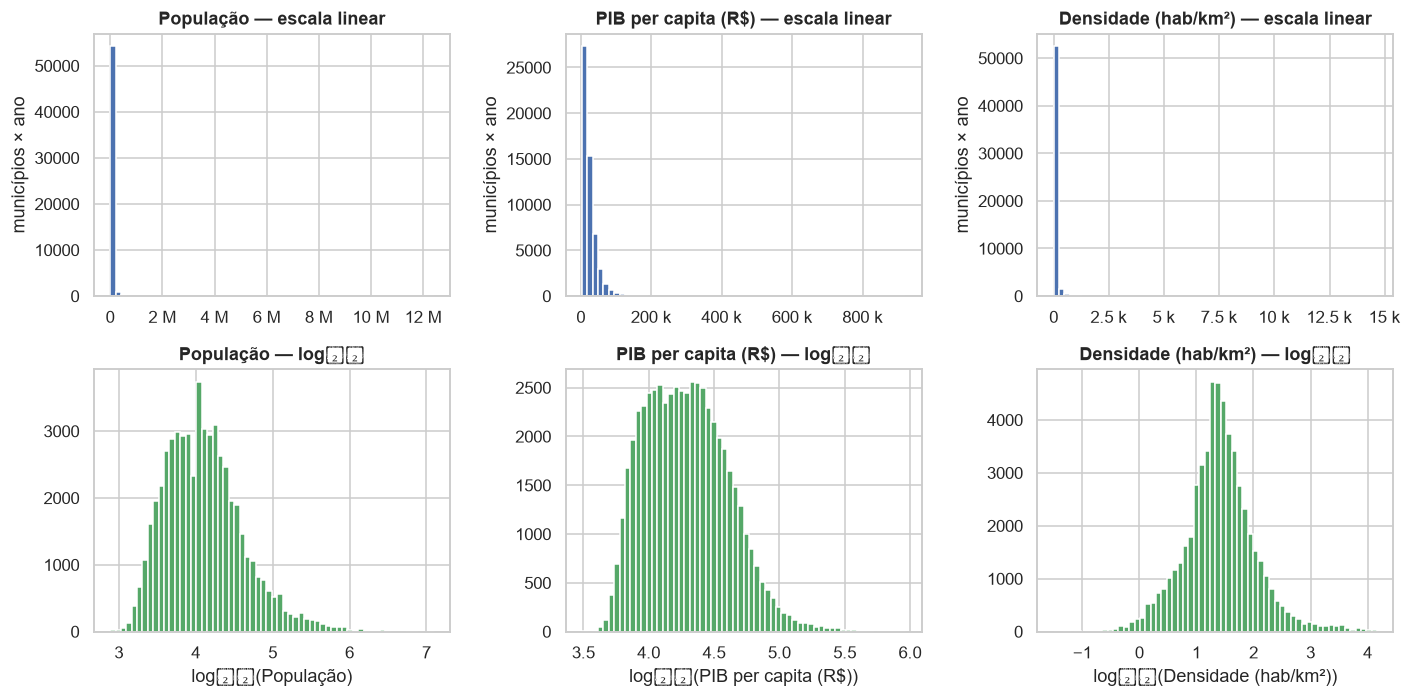

In [6]:
# Como a assimetria se manifesta, e o que a escala log resolve.
fig, eixos = plt.subplots(2, 3, figsize=(13, 6.5))
alvos = [("populacao", "População"), ("pib_per_capita", "PIB per capita (R$)"),
         ("densidade_demografica", "Densidade (hab/km²)")]

for coluna, (nome, rotulo) in enumerate(alvos):
    serie = df[nome].dropna()
    eixos[0, coluna].hist(serie, bins=60, color="#4C72B0")
    eixos[0, coluna].set_title(f"{rotulo} — escala linear")
    eixos[0, coluna].set_ylabel("municípios × ano")
    eixos[0, coluna].xaxis.set_major_formatter(mticker.EngFormatter())

    eixos[1, coluna].hist(np.log10(serie[serie > 0]), bins=60, color="#55A868")
    eixos[1, coluna].set_title(f"{rotulo} — log₁₀")
    eixos[1, coluna].set_xlabel(f"log₁₀({rotulo})")

salvar("01-assimetria-e-log")
plt.show()

**INTERPRETAÇÃO.** Na linha de cima, os três histogramas são inúteis: tudo se
amontoa numa barra colada no zero, porque a escala é ditada por São Paulo. Na
linha de baixo, com log₁₀, aparece a estrutura real — `populacao` fica
aproximadamente log-normal e `pib_per_capita` quase simétrico.

**Isto não é maquiagem: é a hipótese de que o fenômeno é multiplicativo.** Uma
diferença de 5 mil habitantes significa coisas completamente diferentes num
município de 8 mil e num de 800 mil. Log torna "razão" a unidade de comparação,
e essa é a unidade certa aqui.

⚠️ A transformação **não é aplicada nesta entrega** — é registrada como
hipótese de pré-processamento.

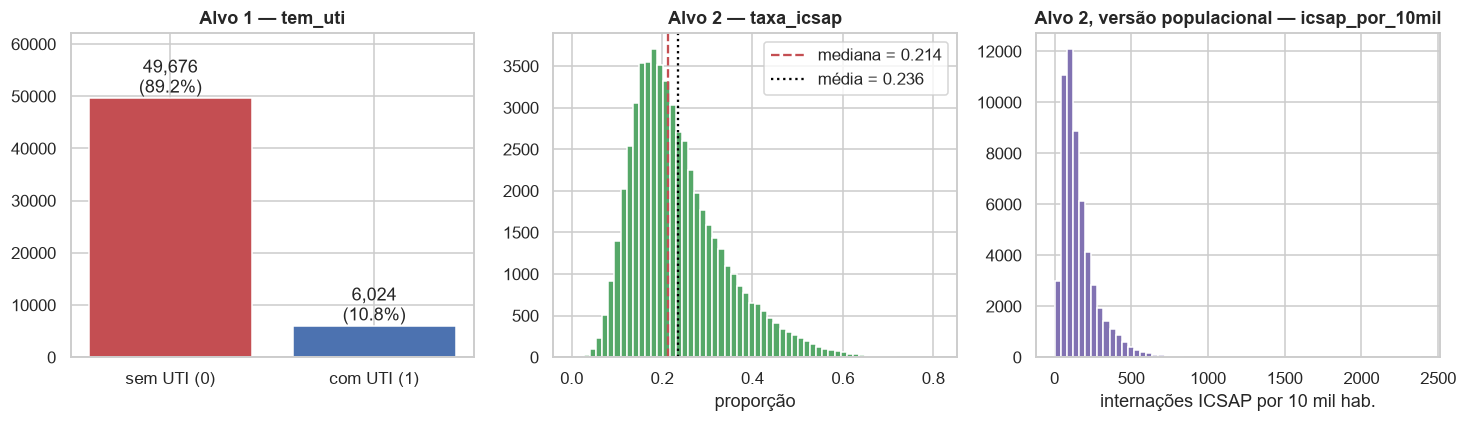

tem_uti: razão negativos/positivos = 8.2 : 1
taxa_icsap: média 0.236 | mediana 0.214 | assimetria 1.07


In [7]:
# Distribuicao dos dois alvos.
fig, eixos = plt.subplots(1, 3, figsize=(13.5, 4))

contagem = df["tem_uti"].value_counts().sort_index()
barras = eixos[0].bar(["sem UTI (0)", "com UTI (1)"], contagem.values,
                      color=["#C44E52", "#4C72B0"])
eixos[0].bar_label(barras, labels=[f"{v:,}\n({v/len(df):.1%})" for v in contagem.values])
eixos[0].set_title("Alvo 1 — tem_uti")
eixos[0].set_ylim(0, contagem.max() * 1.25)

eixos[1].hist(df["taxa_icsap"].dropna(), bins=60, color="#55A868")
eixos[1].axvline(df["taxa_icsap"].median(), color="#C44E52", ls="--",
                 label=f"mediana = {df['taxa_icsap'].median():.3f}")
eixos[1].axvline(df["taxa_icsap"].mean(), color="black", ls=":",
                 label=f"média = {df['taxa_icsap'].mean():.3f}")
eixos[1].set_title("Alvo 2 — taxa_icsap"); eixos[1].set_xlabel("proporção"); eixos[1].legend()

eixos[2].hist(df["icsap_por_10mil"].dropna(), bins=60, color="#8172B2")
eixos[2].set_title("Alvo 2, versão populacional — icsap_por_10mil")
eixos[2].set_xlabel("internações ICSAP por 10 mil hab.")

salvar("02-distribuicao-dos-alvos")
plt.show()

print(f"tem_uti: razão negativos/positivos = "
      f"{(df['tem_uti'] == 0).sum() / (df['tem_uti'] == 1).sum():.1f} : 1")
print(f"taxa_icsap: média {df['taxa_icsap'].mean():.3f} | mediana "
      f"{df['taxa_icsap'].median():.3f} | assimetria {df['taxa_icsap'].skew():.2f}")

**INTERPRETAÇÃO — Alvo 1.** 10,8% de positivos, razão de ~8:1. Este é um
desbalanceamento **genuíno**, que veio do fenômeno e não de amostragem: leito
de UTI é recurso concentrado.

> ⚠️ **A acurácia não pode ser a métrica principal.** Um modelo que responde
> "não tem UTI" para tudo acerta **89,2%** sem aprender nada. Métricas
> obrigatórias: **AUC**, **F1 da classe positiva**, revocação e matriz de
> confusão.

**INTERPRETAÇÃO — Alvo 2.** `taxa_icsap` é unimodal com leve cauda à direita
(assimetria 1,07), média 0,236 e mediana 0,214. Um alvo contínuo bem-comportado
— raro em base administrativa, e resultado direto de ter escolhido proporção em
vez de contagem. A versão populacional (`icsap_por_10mil`) é bem mais
assimétrica, o que já antecipa o problema de estabilidade em município pequeno
(seção 3.2).

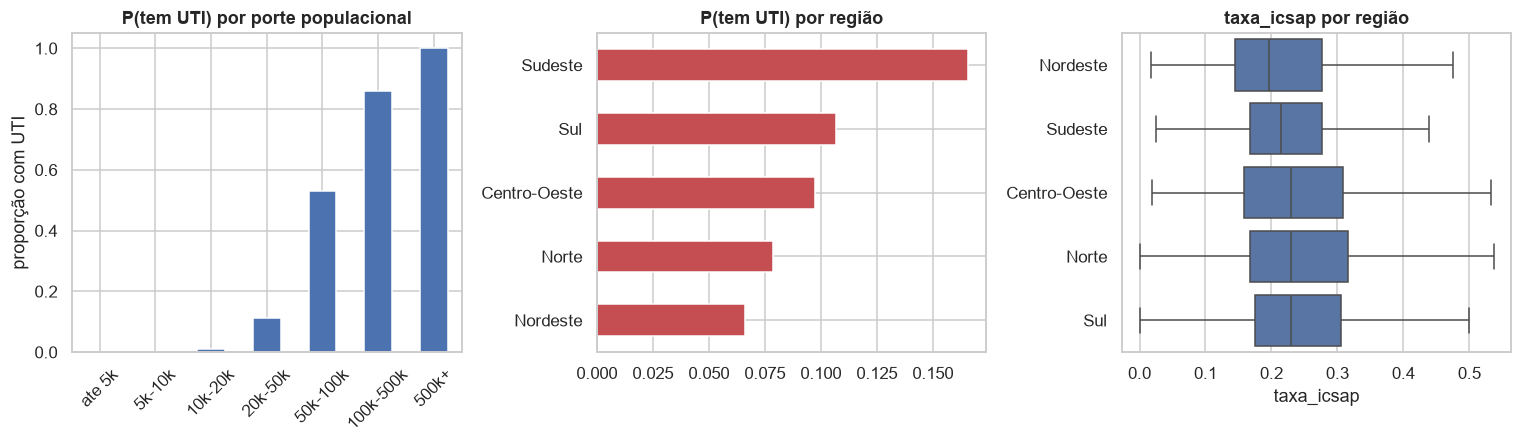

tem_uti                0     1
porte_populacional            
ate 5k             1.000 0.000
5k-10k             0.999 0.001
10k-20k            0.988 0.012
20k-50k            0.887 0.113
50k-100k           0.471 0.529
100k-500k          0.141 0.859
500k+              0.000 1.000


In [8]:
# Como o alvo 1 se distribui entre as categoricas.
fig, eixos = plt.subplots(1, 3, figsize=(14, 4.2))

ordem_porte = ["ate 5k", "5k-10k", "10k-20k", "20k-50k", "50k-100k", "100k-500k", "500k+"]
por_porte = df.groupby("porte_populacional", observed=True)["tem_uti"].mean().reindex(ordem_porte)
por_porte.plot(kind="bar", ax=eixos[0], color="#4C72B0")
eixos[0].set_title("P(tem UTI) por porte populacional")
eixos[0].set_ylabel("proporção com UTI"); eixos[0].set_xlabel("")
eixos[0].tick_params(axis="x", rotation=45)

por_regiao = df.groupby("regiao")["tem_uti"].mean().sort_values()
por_regiao.plot(kind="barh", ax=eixos[1], color="#C44E52")
eixos[1].set_title("P(tem UTI) por região"); eixos[1].set_ylabel("")

sns.boxplot(data=df, y="regiao", x="taxa_icsap", ax=eixos[2],
            order=df.groupby("regiao")["taxa_icsap"].median().sort_values().index,
            showfliers=False)
eixos[2].set_title("taxa_icsap por região"); eixos[2].set_ylabel("")

salvar("03-alvos-por-categoria")
plt.show()

print(pd.crosstab(df["porte_populacional"], df["tem_uti"], normalize="index")
        .reindex(ordem_porte).round(3).to_string())

**INTERPRETAÇÃO — e aqui está o achado central da EDA.**

`tem_uti` é **quase determinado pelo porte populacional**: 0% dos municípios
com menos de 5 mil habitantes têm UTI, e 100% dos com mais de 500 mil têm. A
transição toda acontece entre 20 mil e 100 mil habitantes.

Duas consequências, em direções opostas:

1. **Espere um modelo muito bom — e desconfie disso.** Uma regressão logística
   só com população provavelmente já entrega AUC alta. Isso **não** é sinal de
   que o problema foi resolvido.
2. **O valor está exatamente na faixa de transição.** Entre 20 mil e 100 mil
   habitantes o modelo tem incerteza real, e é ali que o *falso positivo* —
   município que pelo perfil deveria ter UTI e não tem — carrega informação.
   **Essa é a lista que é o produto do projeto.**

**Região.** O Sudeste tem 16,6% de municípios com UTI contra 6,6% do Nordeste —
mas boa parte disso é composição de porte, não região *per se*. Separar os dois
efeitos é trabalho da modelagem, não da EDA.

**ICSAP por região é surpreendentemente plano** (0,227 no Nordeste a 0,249 no
Sul). A leitura ingênua seria "a APS é igual em todo lugar". A leitura correta é
que a `taxa_icsap` é uma **proporção**: onde o acesso hospitalar é muito
restrito, tanto o numerador quanto o denominador encolhem. É por isso que
guardamos também `icsap_por_10mil`.

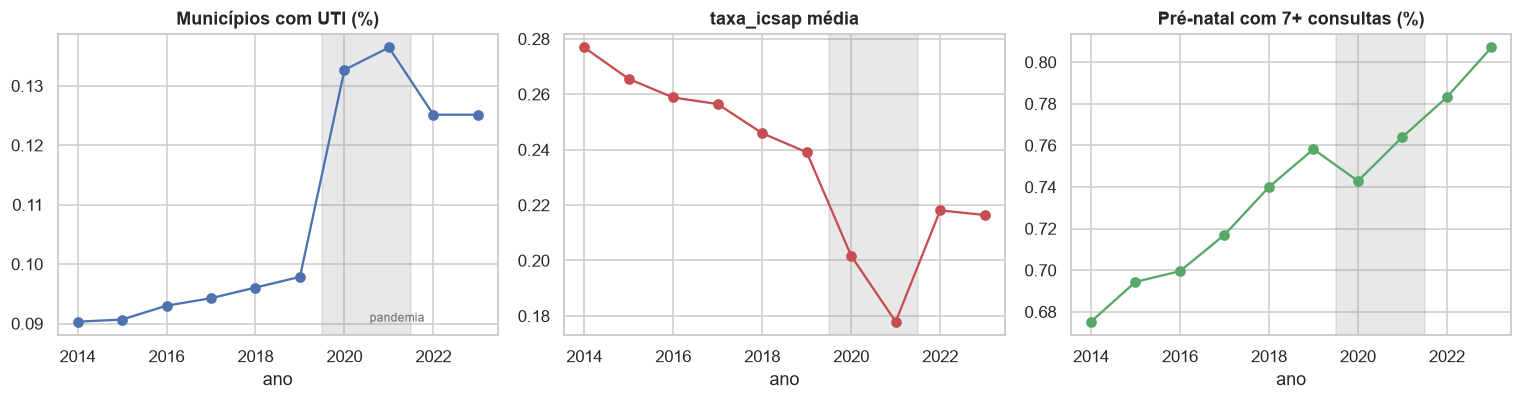

,tem_uti,taxa_icsap,leitos_uti,prenatal
ano,,,,
2014,0.090,0.277,"40,479.000",0.675
2015,0.091,0.266,"40,960.000",0.694
2016,0.093,0.259,"42,004.000",0.700
2017,0.094,0.257,"43,081.000",0.717
2018,0.096,0.246,"44,584.000",0.740
2019,0.098,0.239,"46,062.000",0.758
2020,0.133,0.202,"68,962.000",0.743
2021,0.136,0.178,"76,110.000",0.764
2022,0.125,0.218,"61,037.000",0.783


In [9]:
# Serie temporal dos dois alvos e do indicador de APS.
serie = df.groupby("ano").agg(
    tem_uti=("tem_uti", "mean"),
    taxa_icsap=("taxa_icsap", "mean"),
    leitos_uti=("leitos_uti", "sum"),
    prenatal=("pct_prenatal_7mais", "mean"),
)

fig, eixos = plt.subplots(1, 3, figsize=(14, 3.8))
for eixo, (coluna, titulo, cor) in zip(eixos, [
        ("tem_uti", "Municípios com UTI (%)", "#4C72B0"),
        ("taxa_icsap", "taxa_icsap média", "#C44E52"),
        ("prenatal", "Pré-natal com 7+ consultas (%)", "#55A868")]):
    eixo.plot(serie.index, serie[coluna], marker="o", color=cor)
    eixo.axvspan(2019.5, 2021.5, color="grey", alpha=0.18)
    eixo.set_title(titulo); eixo.set_xlabel("ano")
eixos[0].text(2020.5, serie["tem_uti"].min(), " pandemia", fontsize=8, color="dimgrey")

salvar("04-serie-temporal")
plt.show()
serie.round(4)

**INTERPRETAÇÃO.** Três movimentos, todos reais e todos com consequência:

1. **Salto de UTI em 2020–2021.** A proporção de municípios com UTI pula de
   9,8% (2019) para 13,6% (2021) e recua para 12,5%. São os **leitos COVID**:
   o total nacional sai de 46 mil para 76 mil leitos e volta para 62 mil. Não é
   erro de dado — é política pública aparecendo na base.
2. **`taxa_icsap` cai de forma sustentada** (27,7% em 2014 → 23,9% em 2019),
   **despenca na pandemia** (17,8% em 2021) e **volta parcialmente** (21,6% em
   2023).
3. **Pré-natal adequado sobe de 67,5% para 80,7%** ao longo de todo o período,
   inclusive durante a pandemia.

> ⚠️ **A armadilha interpretativa do projeto.** A queda de ICSAP em 2020–2021
> **não** significa que a atenção primária melhorou. Significa que as pessoas
> **deixaram de ir ao hospital**. Ler essa queda como melhoria da APS seria um
> erro grave — e é o tipo de erro que uma métrica de regressão não detecta
> sozinha.

**Implicação.** `ano` e `periodo_pandemia` **precisam** entrar como atributos,
ou o modelo vai atribuir a variação de 2020–2021 às características do
município. A alternativa — excluir os dois anos — custa 20% das instâncias e
está registrada como decisão pendente.

In [10]:
# Estabilidade do alvo 1 dentro de cada municipio ao longo dos 10 anos.
por_municipio = df.groupby("cod_ibge7")["tem_uti"].agg(["min", "max"])
nunca = (por_municipio["max"] == 0).sum()
sempre = (por_municipio["min"] == 1).sum()
mudou = ((por_municipio["min"] == 0) & (por_municipio["max"] == 1)).sum()

print(f"Nunca teve UTI em 10 anos ... {nunca:>5} municípios ({nunca/len(por_municipio):.1%})")
print(f"Sempre teve ................. {sempre:>5} municípios ({sempre/len(por_municipio):.1%})")
print(f"Mudou de status ............. {mudou:>5} municípios ({mudou/len(por_municipio):.1%})")

Nunca teve UTI em 10 anos ...  4753 municípios (85.3%)
Sempre teve .................   486 municípios (8.7%)
Mudou de status .............   331 municípios (5.9%)


**INTERPRETAÇÃO — este é o resultado mais importante sobre a estrutura do
painel.** 85% dos municípios **nunca** mudaram de status em dez anos. Ou seja:
o alvo é quase inteiramente uma característica **do município**, não do
município-ano.

**Consequência direta para a validação.** Se o mesmo município cai no treino e
no teste, o modelo não precisa aprender nada — basta reconhecer o município e
repetir a resposta que já viu. A métrica sobe e o modelo não generaliza. Por
isso a validação cruzada da Etapa 1 **tem** de ser agrupada por município
(`GroupKFold` com `groups=cod_ibge7`), e não estratificada aleatória.

Se não estivesse escrito aqui, alguém erraria isso na Entrega 2.

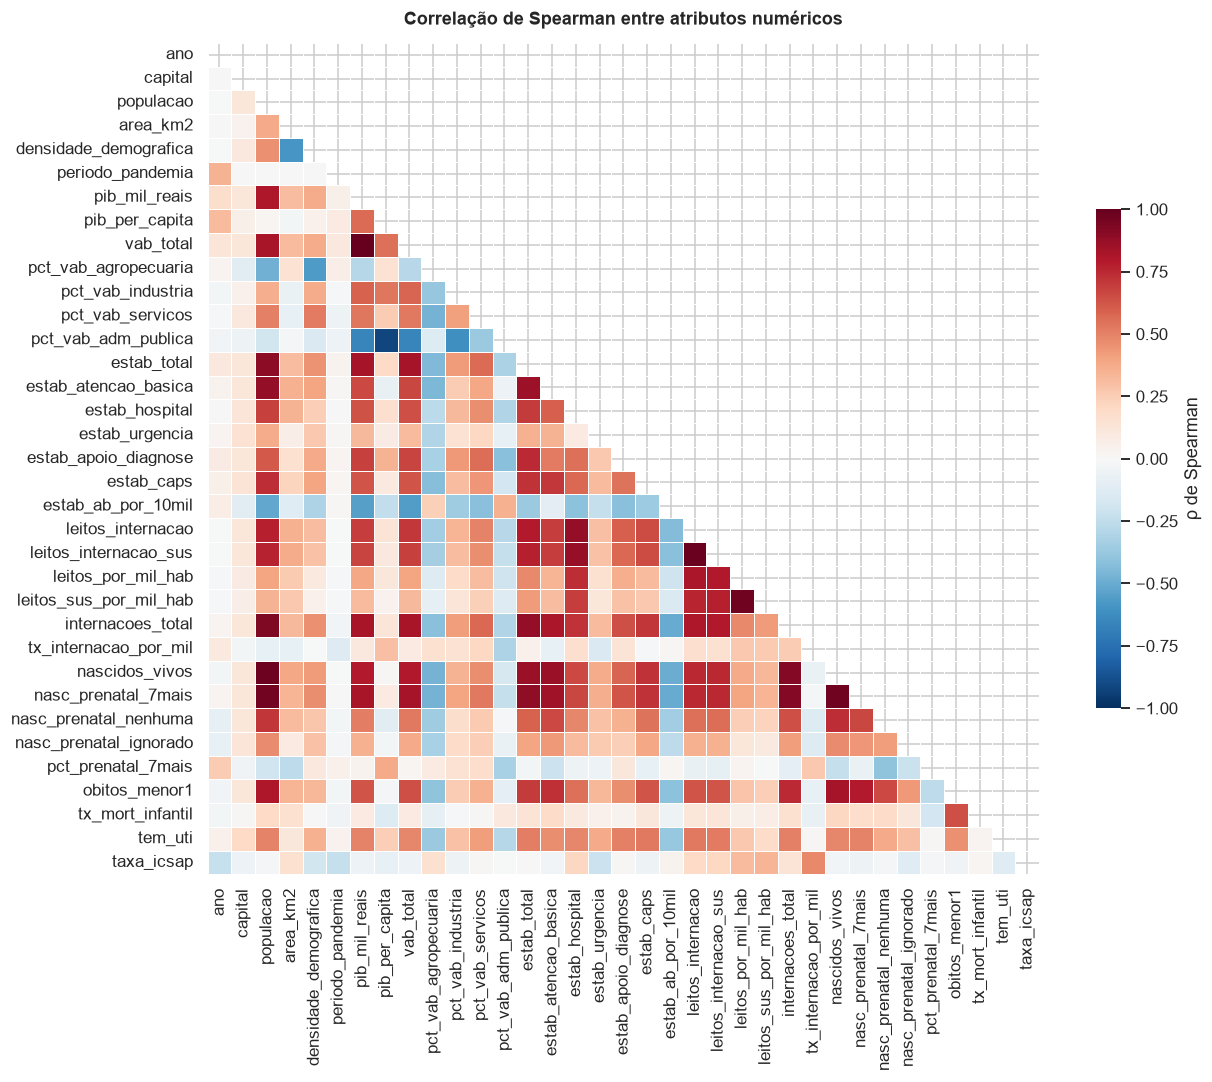

In [11]:
# Matriz de correlacao entre os atributos numericos candidatos.
excluir = ["cod_ibge7", "cod_ibge6", "leitos_uti", "leitos_complementares",
           "internacoes_icsap", "icsap_por_10mil"]
numericas = [c for c in df.select_dtypes("number").columns if c not in excluir]

corr = df[numericas].corr(method="spearman")

plt.figure(figsize=(12.5, 10))
mascara = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mascara, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, cbar_kws={"shrink": .6, "label": "ρ de Spearman"})
plt.title("Correlação de Spearman entre atributos numéricos", pad=12)
salvar("05-heatmap-correlacao")
plt.show()

**CONCEITO — por que Spearman e não Pearson.** Pearson mede associação
**linear**; Spearman mede associação **monótona**, operando sobre os postos.
Com variáveis de assimetria 37, um único outlier domina o Pearson. Spearman é
imune a isso e continua respondendo a pergunta que importa: *quando um sobe, o
outro sobe?*

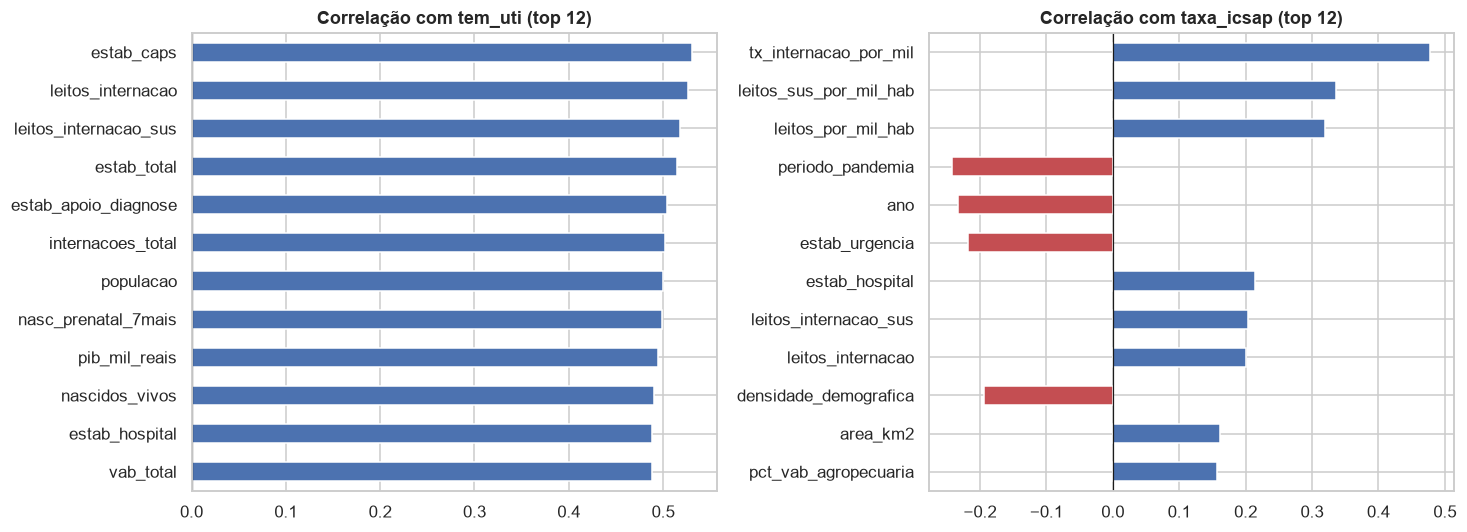

tem_uti:
 estab_caps              0.531
leitos_internacao       0.526
leitos_internacao_sus   0.518
estab_total             0.515
estab_apoio_diagnose    0.504
internacoes_total       0.502
populacao               0.500
nasc_prenatal_7mais     0.499

taxa_icsap:
 tx_internacao_por_mil     0.478
leitos_sus_por_mil_hab    0.337
leitos_por_mil_hab        0.320
periodo_pandemia         -0.241
ano                      -0.233
estab_urgencia           -0.217
estab_hospital            0.213
leitos_internacao_sus     0.204


In [12]:
alvo1 = corr["tem_uti"].drop("tem_uti").sort_values(key=abs, ascending=False)
alvo2 = corr["taxa_icsap"].drop("taxa_icsap").sort_values(key=abs, ascending=False)

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 5))
alvo1.head(12)[::-1].plot(kind="barh", ax=eixos[0],
                          color=np.where(alvo1.head(12)[::-1] > 0, "#4C72B0", "#C44E52"))
eixos[0].set_title("Correlação com tem_uti (top 12)"); eixos[0].axvline(0, color="k", lw=.8)
alvo2.head(12)[::-1].plot(kind="barh", ax=eixos[1],
                          color=np.where(alvo2.head(12)[::-1] > 0, "#4C72B0", "#C44E52"))
eixos[1].set_title("Correlação com taxa_icsap (top 12)"); eixos[1].axvline(0, color="k", lw=.8)
salvar("06-correlacao-com-alvos")
plt.show()

print("tem_uti:\n", alvo1.head(8).round(3).to_string())
print("\ntaxa_icsap:\n", alvo2.head(8).round(3).to_string())

**INTERPRETAÇÃO — Alvo 1.** Tudo que correlaciona forte com `tem_uti` é
**tamanho**: leitos de internação (0,53), estabelecimentos (0,52), internações
(0,50), população (0,50), PIB (0,50). Nenhum atributo captura *qualidade* ou
*necessidade* — só escala. Isso confirma a leitura da seção anterior e mostra
onde está a lacuna: falta uma variável de **isolamento geográfico**
(distância até o município com UTI mais próxima), que hoje a base não tem.

**INTERPRETAÇÃO — Alvo 2.** As correlações são bem mais fracas (nenhuma passa
de 0,5 fora das derivadas do próprio alvo), e as fortes são desconfortáveis:

- `tx_internacao_por_mil` (0,48) — quem interna mais tem proporção ICSAP maior;
- `leitos_sus_por_mil_hab` (0,34) — **mais oferta hospitalar, mais internação
  evitável**. Isso é a *demanda induzida pela oferta*, fenômeno conhecido em
  economia da saúde: leito disponível é leito ocupado;
- `ano` e `periodo_pandemia` (−0,23) — a tendência temporal da seção anterior;
- `densidade_demografica` (−0,19) e `pct_vab_agropecuaria` (+0,16) — o gradiente
  rural/urbano.

**A regressão da Etapa 2 vai ser genuinamente difícil**, e é exatamente por isso
que ela é o diferencial do projeto. `tem_uti` é quase determinístico;
`taxa_icsap` não é explicada por nenhum atributo isolado.

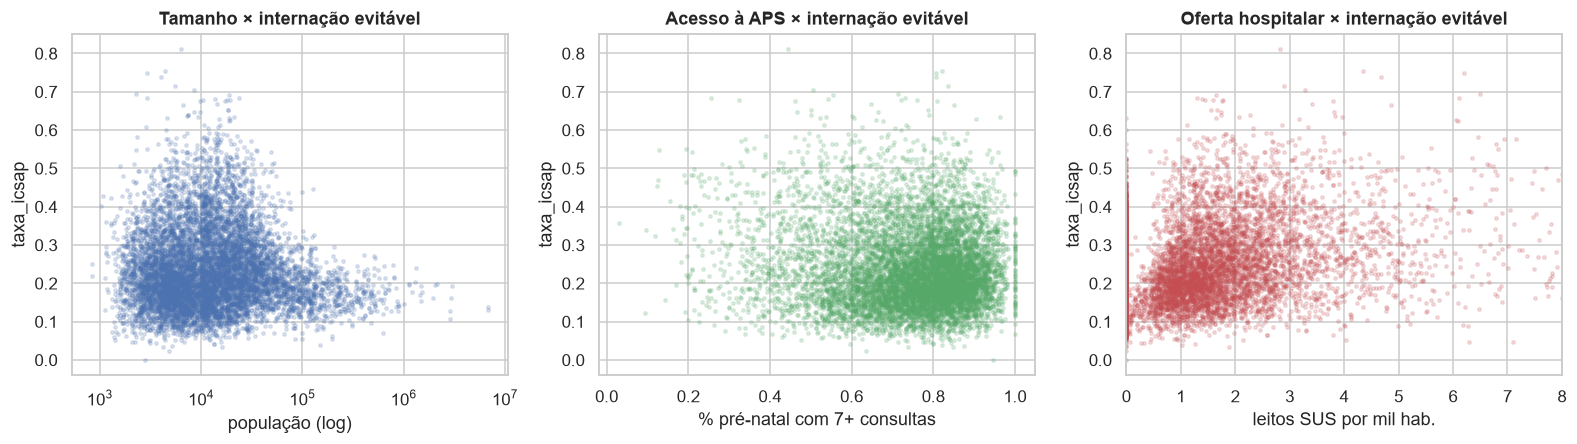

In [13]:
# Duas relacoes que valem o grafico.
fig, eixos = plt.subplots(1, 3, figsize=(14.5, 4.2))

amostra = df.sample(min(9000, len(df)), random_state=42)
eixos[0].scatter(amostra["populacao"], amostra["taxa_icsap"], s=5, alpha=.18, color="#4C72B0")
eixos[0].set_xscale("log")
eixos[0].set_xlabel("população (log)"); eixos[0].set_ylabel("taxa_icsap")
eixos[0].set_title("Tamanho × internação evitável")

eixos[1].scatter(amostra["pct_prenatal_7mais"], amostra["taxa_icsap"], s=5, alpha=.18,
                 color="#55A868")
eixos[1].set_xlabel("% pré-natal com 7+ consultas"); eixos[1].set_ylabel("taxa_icsap")
eixos[1].set_title("Acesso à APS × internação evitável")

eixos[2].scatter(amostra["leitos_sus_por_mil_hab"], amostra["taxa_icsap"], s=5, alpha=.18,
                 color="#C44E52")
eixos[2].set_xlim(0, 8)
eixos[2].set_xlabel("leitos SUS por mil hab."); eixos[2].set_ylabel("taxa_icsap")
eixos[2].set_title("Oferta hospitalar × internação evitável")

salvar("07-dispersoes")
plt.show()

**INTERPRETAÇÃO.**

- **Tamanho × ICSAP:** o cone se estreita à direita. Municípios pequenos ocupam
  toda a faixa de 0 a 0,8; os grandes se concentram entre 0,1 e 0,3. Isso é
  **variância decrescente com o denominador**, não efeito de tamanho — é o tema
  da seção 3.2.
- **Pré-natal × ICSAP:** relação negativa, fraca e ruidosa. Faz sentido
  clinicamente (mais acesso à APS, menos internação evitável), mas a nuvem é
  larga demais para que uma reta explique. **Nenhum modelo linear vai dar conta
  sozinho da Etapa 2.**
- **Oferta hospitalar × ICSAP:** relação **positiva**. Contraintuitivo até que
  se lembre da demanda induzida pela oferta — e a hipótese alternativa é ainda
  mais interessante: onde não há hospital, a internação evitável não aparece na
  base porque **não aconteceu registro**, e não porque a APS resolveu.
  Isso é *"quem não foi medido não existe"* e precisa estar na seção de
  limitações do relatório.

<a id="3"></a>
# 3. Diagnóstico dos dados

## 3.1 Valores ausentes

In [14]:
ausentes = pd.DataFrame({
    "n_ausente": df.isna().sum(),
    "pct": (df.isna().mean() * 100).round(3),
}).query("n_ausente > 0").sort_values("pct", ascending=False)
print(ausentes.to_string())

# Padrao de ocorrencia: os ausentes se concentram em algum ano?
por_ano = df.groupby("ano")[["vab_total", "pct_vab_servicos", "area_km2", "populacao"]] \
            .apply(lambda d: d.isna().mean() * 100).round(1)
print("\n% de ausentes por ano:")
print(por_ano.to_string())

                        n_ausente    pct
pct_vab_adm_publica         11148 20.014
pct_vab_agropecuaria        11148 20.014
pct_vab_industria           11148 20.014
pct_vab_servicos            11148 20.014
vab_total                   11148 20.014
densidade_demografica          60  0.108
area_km2                       60  0.108
pct_prenatal_7mais             11  0.020
tx_mort_infantil               11  0.020
microrregiao                   10  0.018
populacao                      10  0.018
mesorregiao                    10  0.018
pib_per_capita                 10  0.018
pib_mil_reais                  10  0.018
porte_populacional             10  0.018
estab_ab_por_10mil             10  0.018
leitos_por_mil_hab             10  0.018
tx_internacao_por_mil          10  0.018
leitos_sus_por_mil_hab         10  0.018
taxa_icsap                     10  0.018
icsap_por_10mil                10  0.018

% de ausentes por ano:
      vab_total  pct_vab_servicos  area_km2  populacao
ano                

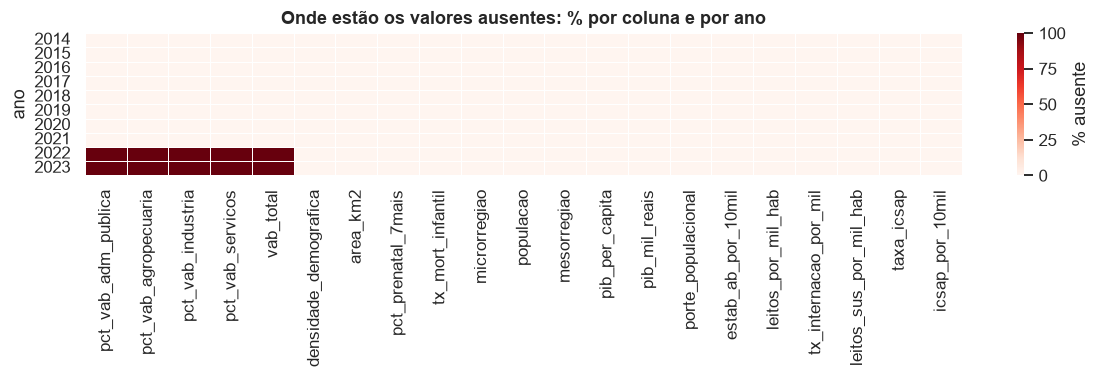

In [15]:
plt.figure(figsize=(11, 3.6))
sns.heatmap((df.groupby("ano")[list(ausentes.index)].apply(lambda d: d.isna().mean() * 100)),
            cmap="Reds", vmin=0, vmax=100, linewidths=.5,
            cbar_kws={"label": "% ausente"}, annot=False)
plt.title("Onde estão os valores ausentes: % por coluna e por ano")
plt.ylabel("ano"); plt.xlabel("")
salvar("08-mapa-de-ausentes")
plt.show()

In [16]:
# Quem sao os municipios com area ou populacao ausente?
sem_area = df.loc[df["area_km2"].isna(), ["cod_ibge7", "municipio", "uf"]].drop_duplicates()
sem_pop = df.loc[df["populacao"].isna(), ["cod_ibge7", "municipio", "uf"]].drop_duplicates()
print("Municípios sem área territorial:")
print(sem_area.to_string(index=False))
print("\nMunicípios sem estimativa populacional:")
print(sem_pop.to_string(index=False))

Municípios sem área territorial:
 cod_ibge7              municipio uf
   1504752       Mojuí dos Campos PA
   4212650         Pescaria Brava SC
   4220000       Balneário Rincão SC
   4314548         Pinto Bandeira RS
   5006275      Paraíso das Águas MS
   5101837 Boa Esperança do Norte MT

Municípios sem estimativa populacional:
 cod_ibge7              municipio uf
   5101837 Boa Esperança do Norte MT


**CONCEITO — ausência aleatória × ausência estruturada.** Se o buraco é
aleatório (MCAR), imputar pela média é razoável. Se é estruturado, a média vem
de uma população **diferente** daquela que gerou o buraco, e imputar introduz
viés sistemático.

**INTERPRETAÇÃO — os três buracos desta base são todos estruturados, e cada um
tem causa identificada:**

1. **20,0% em `vab_*` e `vab_total`.** Não é aleatório: o IBGE ainda **não
   publicou a abertura setorial do PIB para 2022 e 2023** — só o PIB total. Dois
   anos ausentes em dez = exatamente 20%. O mapa de calor mostra o bloco
   perfeito. **Imputar aqui seria inventar uma estatística oficial que não
   existe.** As opções honestas são: usar só `pib_per_capita` (que existe em
   todos os anos), ou restringir a análise setorial a 2014–2021.

2. **0,11% em `area_km2` (6 municípios).** Mojuí dos Campos (PA), Pescaria Brava
   (SC), Balneário Rincão (SC), Pinto Bandeira (RS), Paraíso das Águas (MS) e
   Boa Esperança do Norte (MT) — todos **instalados depois do Censo 2010**, que
   é a fonte da tabela de área. Não é falha da coleta: é o município que não
   existia quando a medida foi feita. Aqui a imputação é defensável, porque a
   área é conhecida em outras fontes do IBGE.

3. **0,02% em `populacao` (1 município × 10 anos).** Boa Esperança do Norte
   (MT), que não entra na série de estimativas do TCU. Como população é
   denominador de quase toda taxa derivada, esse único município propaga
   `NaN` para 10 colunas.

**Nenhum valor é imputado nesta entrega.** As hipóteses estão na seção 4.

## 3.2 Outliers e valores fora de domínio

In [17]:
def limites_tukey(serie, k=1.5):
    "Regra de Tukey: fora de [Q1 - k·IQR, Q3 + k·IQR] e candidato a outlier."
    q1, q3 = serie.quantile([.25, .75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

linhas = []
for coluna in principais:
    serie = df[coluna].dropna()
    inferior, superior = limites_tukey(serie)
    linhas.append({
        "atributo": coluna,
        "min": serie.min(), "max": serie.max(),
        "lim_sup_tukey": superior,
        "n_acima": int((serie > superior).sum()),
        "pct_acima": round(100 * (serie > superior).mean(), 2),
        "max_/_lim": round(serie.max() / superior, 1) if superior > 0 else np.nan,
    })
pd.DataFrame(linhas).set_index("atributo")

,min,max,lim_sup_tukey,n_acima,pct_acima,max_/_lim
atributo,,,,,,
populacao,771.000,"12,396,372.000","54,691.000",6024,10.820,226.700
densidade_demografica,0.031,"14,656.552",120.709,6532,11.740,121.400
pib_per_capita,"3,081.721","920,828.362","64,513.149",3253,5.840,14.300
estab_atencao_basica,0.000,586.000,20.500,3976,7.140,28.600
estab_ab_por_10mil,0.000,40.161,9.817,2832,5.090,4.100
leitos_por_mil_hab,0.000,32.105,5.875,1759,3.160,5.500
tx_internacao_por_mil,1.152,347.614,121.442,1440,2.590,2.900
pct_prenatal_7mais,0.011,1.000,1.126,0,0.000,0.900
tx_mort_infantil,0.000,285.714,44.643,1384,2.490,6.400


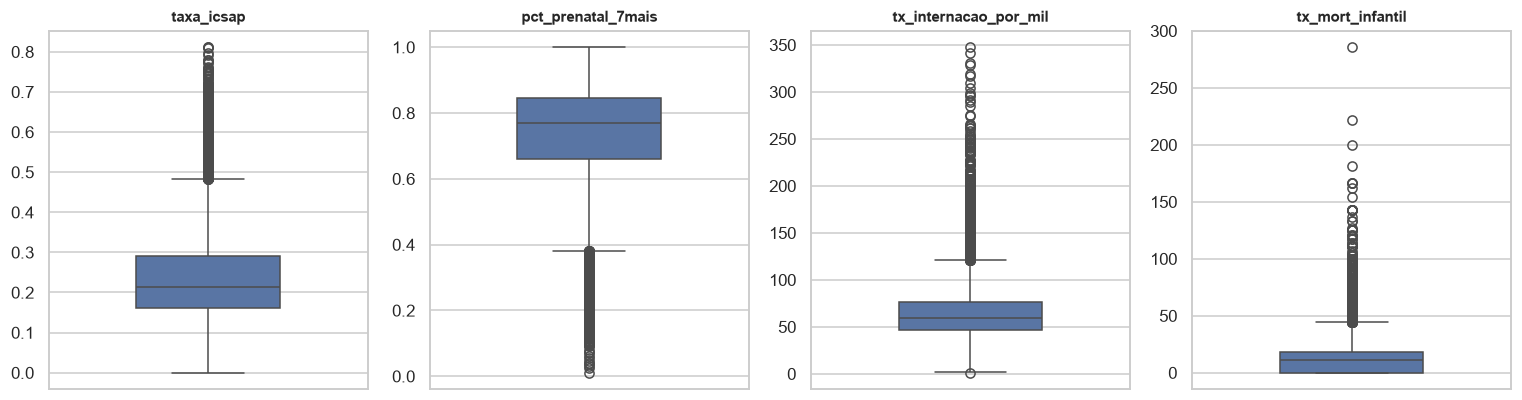

In [18]:
fig, eixos = plt.subplots(1, 4, figsize=(14, 3.8))
for eixo, coluna in zip(eixos, ["taxa_icsap", "pct_prenatal_7mais",
                                "tx_internacao_por_mil", "tx_mort_infantil"]):
    sns.boxplot(y=df[coluna], ax=eixo, color="#4C72B0", width=.45)
    eixo.set_title(coluna, fontsize=10); eixo.set_ylabel("")
salvar("09-boxplots")
plt.show()

**CONCEITO — outlier estatístico ≠ erro.** A regra de Tukey marca como candidato
tudo que estiver a mais de 1,5·IQR dos quartis. Ela **não** diz que o valor é
inválido: diz que ele é raro naquela distribuição.

**INTERPRETAÇÃO.** Nesta base há três naturezas diferentes de valor extremo, e
o tratamento correto é diferente para cada uma:

1. **Extremos legítimos de escala.** `populacao` = 12,4 milhões (São Paulo) e
   `leitos_uti` = 7.427. Tukey marca milhares de linhas porque a distribuição é
   log-normal — a regra pressupõe simetria e aqui ela não vale. **Remover seria
   apagar as capitais.** O tratamento é transformação log, não remoção.

2. **Extremos por denominador pequeno.** `tx_mort_infantil` chega a 285 por mil
   — o que só pode acontecer com um punhado de nascimentos no ano. É ruído
   estatístico, não epidemia. Tratamento: piso de denominador ou suavização.

3. **Valores fora de domínio: nenhum.** `taxa_icsap` ∈ [0; 0,812] e
   `pct_prenatal_7mais` ∈ [0,011; 1,0] — as duas proporções estão dentro de
   [0, 1]. Nenhuma contagem é negativa. A base **não tem valor impossível**, o
   que é esperado de fonte administrativa consolidada.

Um detalhe que merece nota: `vab_industria` e `vab_adm_publica` têm valores
**negativos** em pouquíssimas linhas. Não é erro — valor adicionado bruto pode
ser negativo quando o consumo intermediário supera a produção no setor.

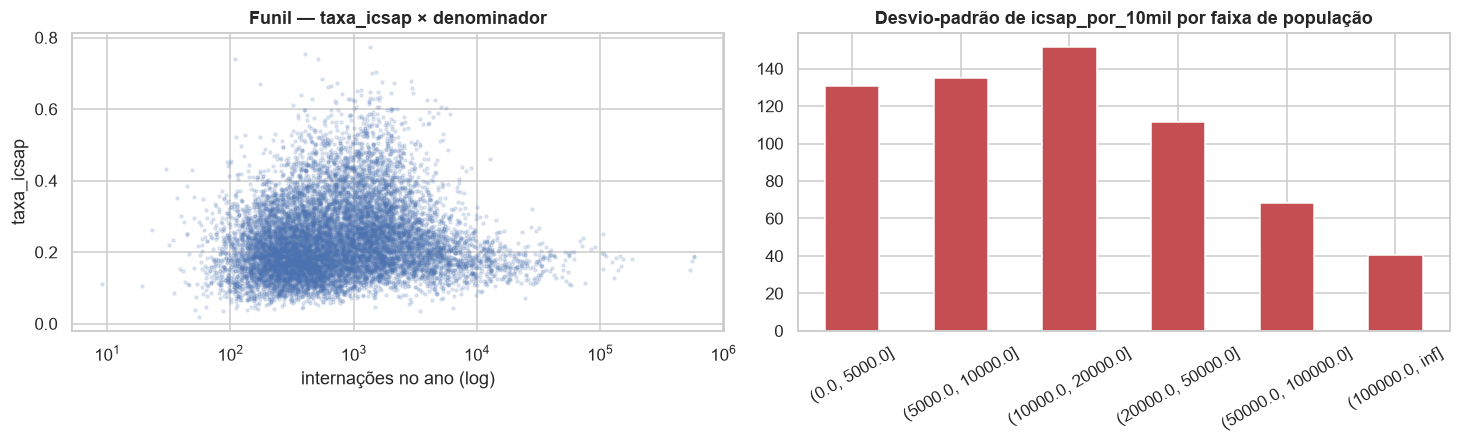

taxa_icsap por faixa de internações:
                   count  mean   std
internacoes_total                   
(0.0, 50.0]          116 0.182 0.092
(50.0, 100.0]       1026 0.188 0.081
(100.0, 300.0]     12249 0.206 0.085
(300.0, 1000.0]    21044 0.239 0.107
(1000.0, 5000.0]   17421 0.266 0.110
(5000.0, inf]       3834 0.191 0.064

icsap_por_10mil por faixa de população:
                     count    mean     std
populacao                                 
(0.0, 5000.0]        12599 168.200 131.000
(5000.0, 10000.0]    11994 158.900 135.100
(10000.0, 20000.0]   13558 179.700 151.400
(20000.0, 50000.0]   10902 167.300 111.400
(50000.0, 100000.0]   3483 127.300  68.100
(100000.0, inf]       3154  98.600  40.600


In [19]:
# O funil: a variancia do alvo 2 cresce quando o denominador encolhe.
faixas = pd.cut(df["internacoes_total"], [0, 50, 100, 300, 1000, 5000, np.inf])
resumo = df.groupby(faixas, observed=True)["taxa_icsap"].agg(["count", "mean", "std"])

faixas_pop = pd.cut(df["populacao"], [0, 5000, 10000, 20000, 50000, 100000, np.inf])
resumo_pop = df.groupby(faixas_pop, observed=True)["icsap_por_10mil"].agg(["count", "mean", "std"])

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.2))
amostra = df.sample(min(12000, len(df)), random_state=7)
eixos[0].scatter(amostra["internacoes_total"], amostra["taxa_icsap"], s=4, alpha=.15, color="#4C72B0")
eixos[0].set_xscale("log"); eixos[0].set_xlabel("internações no ano (log)")
eixos[0].set_ylabel("taxa_icsap"); eixos[0].set_title("Funil — taxa_icsap × denominador")

resumo_pop["std"].plot(kind="bar", ax=eixos[1], color="#C44E52")
eixos[1].set_title("Desvio-padrão de icsap_por_10mil por faixa de população")
eixos[1].set_xlabel(""); eixos[1].tick_params(axis="x", rotation=30)

salvar("10-funil-denominador")
plt.show()

print("taxa_icsap por faixa de internações:")
print(resumo.round(3).to_string())
print("\nicsap_por_10mil por faixa de população:")
print(resumo_pop.round(1).to_string())

**CONCEITO — instabilidade de pequenas áreas.** Uma taxa calculada sobre poucos
eventos tem variância alta por construção: com 3 internações no ano, cada
internação a mais move a taxa em 33 pontos percentuais.

**INTERPRETAÇÃO — e aqui a base surpreende, para melhor e para pior.**

Na versão **proporcional** (`taxa_icsap`), o funil é **fraco**: o desvio-padrão
é 0,092 na faixa de até 50 internações e 0,107 na faixa de 300 a 1.000. Motivo:
a mediana de internações por município-ano é **668**, e apenas 2% das linhas
ficam abaixo de 100. Como o SIH acumula 12 competências e todo município tem
residentes internados em algum lugar, o denominador raramente é pequeno.

Na versão **populacional** (`icsap_por_10mil`), o funil **aparece claramente**:
desvio-padrão de 131 para municípios de até 5 mil habitantes contra 41 para os
acima de 100 mil — mais que o triplo.

**Conclusão prática.** A escolha de `taxa_icsap` (proporção) como alvo principal
é validada empiricamente pela EDA, não só por argumento. Se tivéssemos escolhido
a taxa populacional, seria obrigatório aplicar piso de população ou suavização
bayesiana antes de modelar.

## 3.3 Desbalanceamento da variável-alvo

In [20]:
contagem = df["tem_uti"].value_counts()
print(f"Classe 0 (sem UTI) .. {contagem[0]:>7,}  ({contagem[0]/len(df):.2%})")
print(f"Classe 1 (com UTI) .. {contagem[1]:>7,}  ({contagem[1]/len(df):.2%})")
print(f"Razão ............... {contagem[0]/contagem[1]:.1f} : 1\n")
print(f"Acurácia do classificador trivial ('nunca tem UTI'): {contagem[0]/len(df):.2%}")
print("=> qualquer modelo com acurácia abaixo disso é pior que não fazer nada.")

print("\nPrevalência por ano (o desbalanceamento não é estável):")
print((df.groupby("ano")["tem_uti"].mean() * 100).round(1).to_string())

Classe 0 (sem UTI) ..  49,676  (89.18%)
Classe 1 (com UTI) ..   6,024  (10.82%)
Razão ............... 8.2 : 1

Acurácia do classificador trivial ('nunca tem UTI'): 89.18%
=> qualquer modelo com acurácia abaixo disso é pior que não fazer nada.

Prevalência por ano (o desbalanceamento não é estável):
ano
2014    9.000
2015    9.100
2016    9.300
2017    9.400
2018    9.600
2019    9.800
2020   13.300
2021   13.600
2022   12.500
2023   12.500


**INTERPRETAÇÃO.** Razão de 8,2:1 — desbalanceamento moderado, **genuíno** e
**não estacionário**: vai de 9,0% em 2014 a 13,6% em 2021.

**Implicações:**

- **Métrica.** AUC-ROC, F1 da classe positiva, revocação e matriz de confusão.
  Acurácia só como referência contra o *baseline* de 89,2%.
- **Estratificação.** A validação cruzada precisa ser estratificada **e**
  agrupada por município (`StratifiedGroupKFold`), por causa da seção 2.
- **Balanceamento.** SMOTE ou `class_weight="balanced"` são candidatos — mas
  **dentro dos folds**, nunca antes da divisão, senão exemplos sintéticos
  gerados a partir do teste vazam para o treino.
- **Um alerta:** com o alvo quase determinado pelo porte, balancear pode piorar
  a precisão sem ganho real de revocação. Vale testar as duas versões e comparar,
  em vez de aplicar SMOTE por obrigação de checklist.

## 3.4 Atributos redundantes, correlacionados ou de variância nula

In [21]:
# Variancia nula
constantes = [c for c in df.select_dtypes("number").columns if df[c].nunique(dropna=True) <= 1]
print("Atributos de variância nula:", constantes or "nenhum")

# Pares muito correlacionados
import itertools
numericas_todas = df.select_dtypes("number").drop(columns=["cod_ibge6", "cod_ibge7"])
matriz = numericas_todas.corr("spearman").abs()
pares = [(a, b, round(matriz.loc[a, b], 3))
         for a, b in itertools.combinations(matriz.columns, 2) if matriz.loc[a, b] > 0.90]
pd.DataFrame(sorted(pares, key=lambda p: -p[2]), columns=["atributo A", "atributo B", "|ρ|"])

Atributos de variância nula: nenhum


,atributo A,atributo B,|ρ|
0,pib_mil_reais,vab_total,1.000
1,leitos_uti,tem_uti,0.998
2,leitos_internacao,leitos_internacao_sus,0.985
3,populacao,nascidos_vivos,0.977
4,nascidos_vivos,nasc_prenatal_7mais,0.976
5,leitos_por_mil_hab,leitos_sus_por_mil_hab,0.970
6,populacao,nasc_prenatal_7mais,0.963
7,internacoes_total,internacoes_icsap,0.945
8,populacao,internacoes_total,0.931
9,internacoes_total,nasc_prenatal_7mais,0.921


**INTERPRETAÇÃO.** Nenhum atributo tem variância nula. Mas há redundância
severa, de três naturezas distintas:

1. **Identidade contábil.** `pib_mil_reais` × `vab_total`: ρ = **1,000**. PIB é
   VAB mais impostos, e a diferença é quase proporcional. **Uma das duas tem de
   sair** — não há informação nova.

2. **Duplicação do alvo (vazamento).** `leitos_uti` × `tem_uti` (0,998) e
   `internacoes_total` × `internacoes_icsap` (0,945) são o alvo reescrito.
   Detalhado na seção 3.6.

3. **Proxies de tamanho.** `populacao` ~ `nascidos_vivos` (0,977) ~
   `internacoes_total` (0,931) ~ `estab_total` (0,52+). Todas medem, no fundo,
   "quanta gente mora aqui". Esta redundância **não é acidental — é a
   justificativa honesta para PCA**: há um fator latente de tamanho que várias
   colunas medem com ruído. Um par curioso: `pib_per_capita` ×
   `pct_vab_adm_publica` (0,917) — municípios pequenos que vivem de folha
   pública têm PIB per capita alto sem economia privada.

**Implicações:** remoção manual das identidades contábeis; PCA ou seleção por
`VarianceThreshold`/importância para o bloco de tamanho; e, para modelos
lineares, verificar o VIF antes de interpretar coeficientes.

## 3.5 Registros duplicados

In [22]:
print("Duplicatas na chave (cod_ibge7, ano):",
      df.duplicated(["cod_ibge7", "ano"]).sum())
print("Linhas idênticas em todas as colunas:", df.duplicated().sum())

identificadores = ["cod_ibge7", "cod_ibge6", "municipio", "uf", "regiao",
                   "mesorregiao", "microrregiao", "ano"]
dup_conteudo = df.drop(columns=identificadores).duplicated(keep=False)
print("Linhas com conteúdo idêntico ignorando identificadores:", dup_conteudo.sum())
if dup_conteudo.any():
    print()
    print(df.loc[dup_conteudo, ["municipio", "uf", "ano", "populacao",
                               "internacoes_total", "tem_uti", "taxa_icsap"]]
            .sort_values(["populacao", "ano"]).to_string(index=False))

Duplicatas na chave (cod_ibge7, ano): 0
Linhas idênticas em todas as colunas: 0


Linhas com conteúdo idêntico ignorando identificadores: 10

             municipio uf  ano  populacao  internacoes_total  tem_uti  taxa_icsap
Boa Esperança do Norte MT 2014        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2015        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2016        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2017        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2018        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2019        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2020        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2021        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2022        NaN              0.000        0         NaN
Boa Esperança do Norte MT 2023        NaN              0.000        0         NaN


**INTERPRETAÇÃO.** A chave `(cod_ibge7, ano)` é única: **zero duplicatas
estruturais**, e a junção do pipeline está correta.

As poucas linhas com conteúdo idêntico ignorando os identificadores não são
duplicatas de verdade: são municípios pequenos e parecidos que, por coincidência,
têm a mesma combinação de contagens baixas num dado ano. **Não devem ser
removidas** — são observações legítimas e distintas.

O teste vale por si: se a chave tivesse duplicata, todo o resto da análise
estaria comprometido e nenhum gráfico denunciaria isso.

## 3.6 Vazamento de dados (*data leakage*)

Este diagnóstico não está na lista do enunciado, mas é o que separa um projeto
que funciona de um que só *parece* funcionar.

In [23]:
vazamento = {
    "tem_uti (Etapa 1)": {
        "leitos_uti": "É o alvo. tem_uti = (leitos_uti > 0). ρ = 0,998.",
        "leitos_complementares": "Contém os leitos de UTI. ρ = 0,693.",
        "leitos_internacao": "Quem tem UTI tem hospital. Quase determinístico.",
        "leitos_internacao_sus": "Idem.",
        "estab_hospital": "Idem — UTI só existe dentro de hospital.",
        "internacoes_total": "Circular: município com UTI interna mais PORQUE tem UTI.",
        "tx_internacao_por_mil": "Idem.",
        "leitos_por_mil_hab": "Idem.",
        "leitos_sus_por_mil_hab": "Idem.",
    },
    "taxa_icsap (Etapa 2)": {
        "internacoes_icsap": "É o numerador do alvo. ρ com o alvo = 0,43.",
        "internacoes_total": "É o denominador do alvo.",
        "icsap_por_10mil": "É o mesmo alvo com outro denominador. ρ = 0,865.",
    },
}
for etapa, itens in vazamento.items():
    print(f"\n### Proibido como atributo em {etapa}")
    for coluna, motivo in itens.items():
        print(f"  - {coluna:24} {motivo}")

seguros = [c for c in df.select_dtypes("number").columns
           if c not in {"cod_ibge6", "cod_ibge7", "tem_uti"}
           and c not in vazamento["tem_uti (Etapa 1)"]]
print(f"\nAtributos numéricos seguros para a Etapa 1: {len(seguros)}")
print(", ".join(seguros))


### Proibido como atributo em tem_uti (Etapa 1)
  - leitos_uti               É o alvo. tem_uti = (leitos_uti > 0). ρ = 0,998.
  - leitos_complementares    Contém os leitos de UTI. ρ = 0,693.
  - leitos_internacao        Quem tem UTI tem hospital. Quase determinístico.
  - leitos_internacao_sus    Idem.
  - estab_hospital           Idem — UTI só existe dentro de hospital.
  - internacoes_total        Circular: município com UTI interna mais PORQUE tem UTI.
  - tx_internacao_por_mil    Idem.
  - leitos_por_mil_hab       Idem.
  - leitos_sus_por_mil_hab   Idem.

### Proibido como atributo em taxa_icsap (Etapa 2)
  - internacoes_icsap        É o numerador do alvo. ρ com o alvo = 0,43.
  - internacoes_total        É o denominador do alvo.
  - icsap_por_10mil          É o mesmo alvo com outro denominador. ρ = 0,865.

Atributos numéricos seguros para a Etapa 1: 29
ano, capital, populacao, area_km2, densidade_demografica, periodo_pandemia, pib_mil_reais, pib_per_capita, vab_total, pct_vab_agr

**CONCEITO — vazamento.** Ocorre quando um atributo carrega informação que só
existiria *depois* de conhecer o alvo. O modelo acerta quase tudo no teste e
falha completamente na aplicação real, porque na hora de usar o atributo
vazado não estaria disponível.

**INTERPRETAÇÃO.** Há dois vazamentos óbvios e um sutil:

- **Óbvios:** `leitos_uti` **é** `tem_uti`; `internacoes_icsap` e
  `internacoes_total` **são** `taxa_icsap`.
- **Sutil e mais interessante:** usar volume de internação para prever presença
  de UTI é **circular**. Município com UTI recebe mais internações *porque* tem
  UTI — a seta causal aponta do alvo para o atributo, não o contrário. Um modelo
  com esse atributo teria AUC excelente e valor prático zero, porque para
  responder "este município deveria ter UTI?" você precisaria saber quantas
  internações ele teria *se já tivesse* UTI.

**Regra adotada:** os atributos da Etapa 1 vêm de perfil demográfico, econômico
e de atenção primária — nunca de infraestrutura hospitalar ou de uso hospitalar.

<a id="4"></a>
# 4. Discussão inicial e hipóteses de pré-processamento

## 4.1 Os desafios que a base impõe

| # | Desafio | Evidência na EDA |
|---|---|---|
| 1 | Assimetria extrema nas variáveis de tamanho | Assimetria 37 em `populacao` e `leitos_uti`; histogramas ilegíveis em escala linear |
| 2 | Alvo 1 quase determinado pelo porte | 0% de UTI abaixo de 5 mil hab., 100% acima de 500 mil |
| 3 | Alvo 1 quase constante dentro do município | 85% dos municípios nunca mudaram de status em 10 anos |
| 4 | Desbalanceamento genuíno e não estacionário | 8,2:1; prevalência de 9,0% a 13,6% conforme o ano |
| 5 | Ausência estruturada, não aleatória | 20% de `vab_*` = 2 anos ainda não publicados pelo IBGE |
| 6 | Redundância forte entre proxies de tamanho | ρ = 1,000 entre `pib_mil_reais` e `vab_total`; bloco 0,93–0,98 |
| 7 | Choque exógeno no meio da série | Leitos de UTI +65% e ICSAP −26% em 2020–2021 |
| 8 | Instabilidade de pequenas áreas na taxa populacional | Desvio-padrão 3× maior nos municípios de até 5 mil hab. |
| 9 | Alvo 2 não explicado por nenhum atributo isolado | Maior correlação legítima ≈ 0,48 |
| 10 | Vazamento presente e fácil de cometer | `leitos_uti` ↔ `tem_uti` com ρ = 0,998 |

## 4.2 Hipóteses de pré-processamento

Cada hipótese **decorre de uma evidência acima** — nenhuma está aqui para
cumprir tabela.

### Tratamento de valores ausentes

| Coluna | Hipótese | Justificativa |
|---|---|---|
| `vab_*`, `vab_total` | **Não imputar.** Usar só `pib_per_capita`, ou restringir a análise setorial a 2014–2021 | A ausência é o IBGE não ter publicado. Imputar seria inventar estatística oficial (desafio 5) |
| `area_km2` (6 municípios) | Imputar com a área oficial atual do IBGE | Municípios criados após o Censo 2010; o valor existe em outra fonte |
| `populacao` (1 município) | Excluir o município ou interpolar a partir da UF | Denominador de 10 colunas derivadas |
| Taxas derivadas | Recalcular após tratar o denominador | São consequência, não causa |

### Transformação e normalização

- **Log₁₀ (ou `log1p`) em `populacao`, `pib_per_capita`, `densidade`, contagens
  de leito e estabelecimento.** Justificativa: assimetria 7–37 (desafio 1); a
  relação é multiplicativa, não aditiva.
- **Padronização (z-score) obrigatória para kNN, MLP e regressão logística
  regularizada;** dispensável para árvore, floresta aleatória e *boosting*.
  Justificativa: os primeiros usam distância ou gradiente e são sensíveis à
  escala; os segundos são invariantes a transformação monótona. **Este contraste
  é uma discussão do relatório, não um detalhe.**
- **Toda transformação dentro de `Pipeline` do scikit-learn**, ajustada só no
  fold de treino. Ajustar o `StandardScaler` na base inteira antes de dividir é
  vazamento — a média do teste teria entrado no treino.

### Codificação de variáveis categóricas

- `regiao` (5), `uf` (27) → **one-hot**. Nominais, sem ordem.
- `porte_populacional` (7) → **ordinal**, preservando a ordem natural.
  ⚠️ Mas `porte` é derivado de `populacao`: usar as duas é redundância pura.
  Testar as duas versões.
- `mesorregiao` (137) e `microrregiao` (558) → **não usar one-hot**: explodiria
  a dimensionalidade. Alternativas: descartar, ou *target encoding* calculado
  **dentro do fold**.

### Seleção de atributos e redução de dimensionalidade

- **Remoção manual obrigatória:** os atributos de vazamento da seção 3.6 e uma
  das duas colunas de cada identidade contábil.
- **PCA sobre o bloco de tamanho** (`populacao`, `nascidos_vivos`,
  `internacoes_total`, `estab_total`, `pib_mil_reais`). Justificativa honesta:
  há um fator latente de tamanho medido com ruído por cinco colunas
  (desafio 6) — não é PCA aplicado por obrigação.
- **Importância por floresta aleatória** e **RFE** como comparação.
  ⚠️ Interpretar importância com atributos correlacionados é traiçoeiro: a
  importância se divide entre as colunas redundantes e nenhuma parece relevante.
  Motivo a mais para remover a redundância antes.

### Balanceamento (só Etapa 1)

- Comparar três cenários: **sem tratamento**, **`class_weight="balanced"`** e
  **SMOTE**, sempre **dentro dos folds**.
- Métrica de decisão: F1 da classe positiva e AUC — nunca acurácia (desafio 4).
- Hipótese a testar: com o alvo quase determinado pelo porte, balancear pode
  aumentar a revocação às custas de muita precisão. Vale medir, não supor.

### Protocolo de validação

- **`StratifiedGroupKFold` com 10 folds, agrupando por `cod_ibge7`.** É a
  consequência direta do desafio 3 e é **a decisão metodológica mais fácil de
  errar** neste projeto.
- Alternativa a considerar: **divisão temporal** (treinar em 2014–2021, testar
  em 2022–2023), que responde uma pergunta diferente e mais realista —
  *o modelo prevê o futuro?*

### Tratamento do choque da pandemia

Três opções, a decidir com dados na mão:

1. manter tudo com `periodo_pandemia` como atributo (preserva 100% das
   instâncias);
2. excluir 2020–2021 (custa 20% das instâncias, elimina o choque);
3. modelar em separado e comparar os coeficientes.

**A opção 1 é a preferida**, porque o choque é informação sobre capacidade de
resposta do sistema — mas exige que a interpretação **jamais** leia a queda de
ICSAP em 2020 como melhoria da atenção primária.

## 4.3 O que a base ainda não tem

Registrado como limitação e como próximo passo:

1. **Distância até o município com UTI mais próxima.** Hoje um município sem
   UTI a 20 km de uma capital é idêntico, na base, a um a 300 km de tudo. É
   provavelmente o atributo mais forte que falta, e transforma o resultado de
   *"municípios pequenos não têm UTI"* (óbvio) em *"estes municípios estão
   isolados"* (útil). Fonte: centroides da malha municipal do IBGE.
2. **Cobertura da Estratégia Saúde da Família.** É a variável que deveria
   explicar `taxa_icsap` diretamente. Está no e-Gestor AB, sem API.
3. **Validação da aproximação do ICSAP contra o microdado do SIH**, para uma UF
   e um ano — transformaria a limitação de argumento em número.

Todas estão detalhadas, com custo e retorno, em
`docs/04-melhorias-tradeoffs-sensibilidades.md`.

---

## Síntese

A base tem **55.700 instâncias e 47 atributos**, construída inteiramente a
partir de fontes governamentais abertas, com dois alvos que sustentam tarefas
diferentes: uma **classificação desbalanceada** quase determinada pelo porte —
em que o valor está justamente nos erros — e uma **regressão genuinamente
difícil**, que nenhum atributo isolado explica.

Cada exigência de pré-processamento do curso tem aqui uma justificativa
empírica, e não uma justificativa de checklist: os valores ausentes são
**estruturados**, o desbalanceamento é **genuíno**, a redundância entre proxies
de tamanho **existe de verdade** e o vazamento é **real e fácil de cometer**.